# Regime Adaptive Portfolio — Exploration

This notebook walks through the three core components of the project:
1. HMM regime detection  what the model learned and when it detected each regime
2. Optimizer comparison  how each optimizer allocates across assets
3. Backtest results  equity curve, drawdown, and performance metrics


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

REGIME_COLORS = {"Bull": "#2ecc71", "Bear": "#e74c3c", "Sideways": "#f39c12", "Crash": "#8e44ad"}


## 1. Regime Detection

The HMM labels each trading day as Bull, Bear, Sideways, or Crash based on three features:
- **SPY log return**  daily return signal
- **Rolling volatility**  21-day annualized volatility
- **Rolling correlation** — 63-day mean pairwise correlation across assets

In [2]:
# Load data
regimes = pd.read_parquet("../data/regimes.parquet")
features = pd.read_parquet("../data/processed/features.parquet")
returns = pd.read_parquet("../data/processed/returns.parquet")

print(f"Date range: {regimes.index.min().date()} to {regimes.index.max().date()}")
print(f"Regime counts:\n{regimes['regime'].value_counts()}")

Date range: 2006-07-05 to 2024-12-30
Regime counts:
regime
Bear        1448
Bull        1309
Sideways    1099
Crash        764
Name: count, dtype: int64


### 1.1 Regime Timeline

How the HMM classified each day over the full 20-year period.

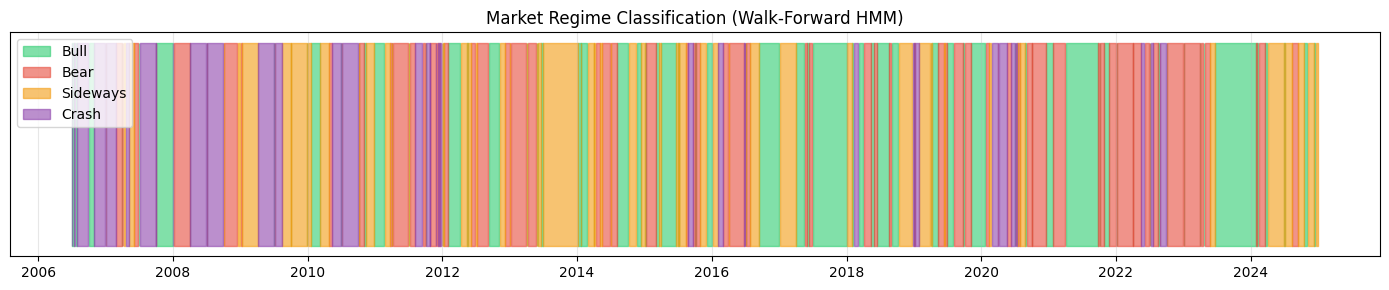

In [3]:
fig, ax = plt.subplots(figsize=(14, 3))

for regime, color in REGIME_COLORS.items():
    mask = regimes["regime"] == regime
    ax.fill_between(regimes.index, 0, 1,
                    where=mask,
                    color=color, alpha=0.6,
                    label=regime)

ax.set_yticks([])
ax.set_title("Market Regime Classification (Walk-Forward HMM)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 1.2 Feature Distributions by Regime

What each regime looks like in terms of the three input features.

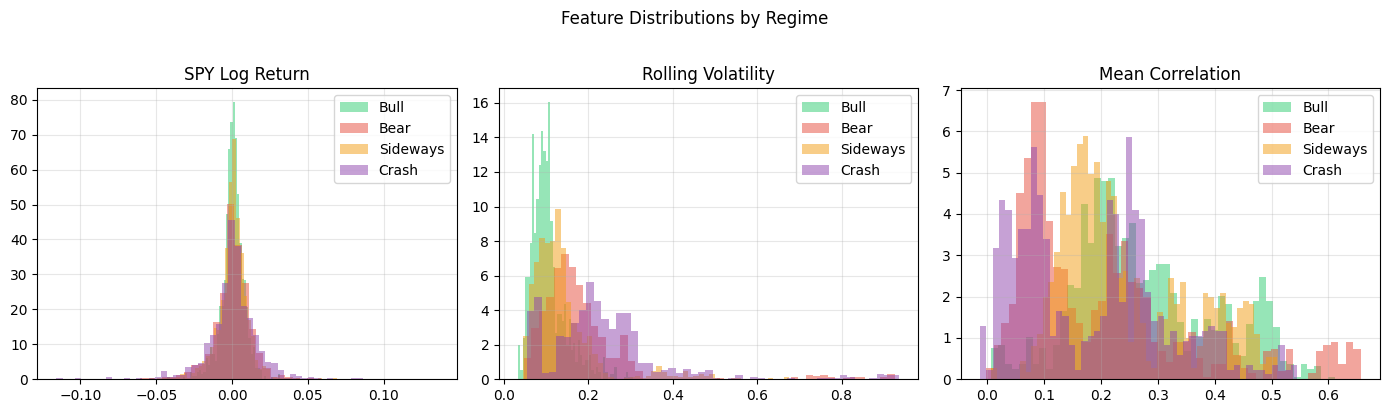

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features_aligned = features.loc[regimes.index]
features_aligned["regime"] = regimes["regime"]

feature_cols = {
    "spy_return": "SPY Log Return",
    "spy_vol": "Rolling Volatility",
    "mean_corr": "Mean Correlation"
}

for ax, (col, label) in zip(axes, feature_cols.items()):
    for regime, color in REGIME_COLORS.items():
        subset = features_aligned[features_aligned["regime"] == regime][col]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=regime, density=True)
    ax.set_title(label)
    ax.legend()

plt.suptitle("Feature Distributions by Regime", y=1.02)
plt.tight_layout()
plt.show()

## 2. Optimizer Comparison

Each regime triggers a different optimizer. Here we compare the resulting asset allocations.

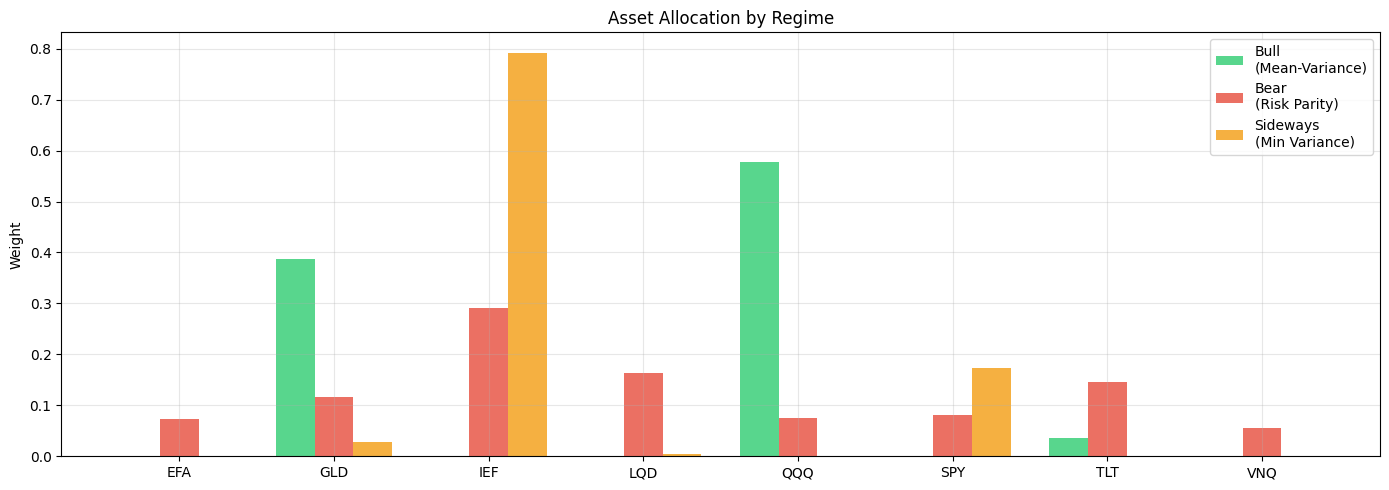

In [5]:
from optimization.mean_var import max_sharpe
from optimization.risk_parity import risk_parity
from optimization.min_variance import min_variance

assets = returns.columns.tolist()

w_bull     = max_sharpe(returns)
w_bear     = risk_parity(returns)
w_sideways = min_variance(returns)

labels = ["Bull\n(Mean-Variance)", "Bear\n(Risk Parity)", "Sideways\n(Min Variance)"]
weights = [w_bull, w_bear, w_sideways]
colors  = [REGIME_COLORS["Bull"], REGIME_COLORS["Bear"], REGIME_COLORS["Sideways"]]

x = np.arange(len(assets))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (w, label, color) in enumerate(zip(weights, labels, colors)):
    ax.bar(x + i * width, w, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(assets)
ax.set_ylabel("Weight")
ax.set_title("Asset Allocation by Regime")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Backtest Results

Portfolio performance versus SPY buy-and-hold over the full period.

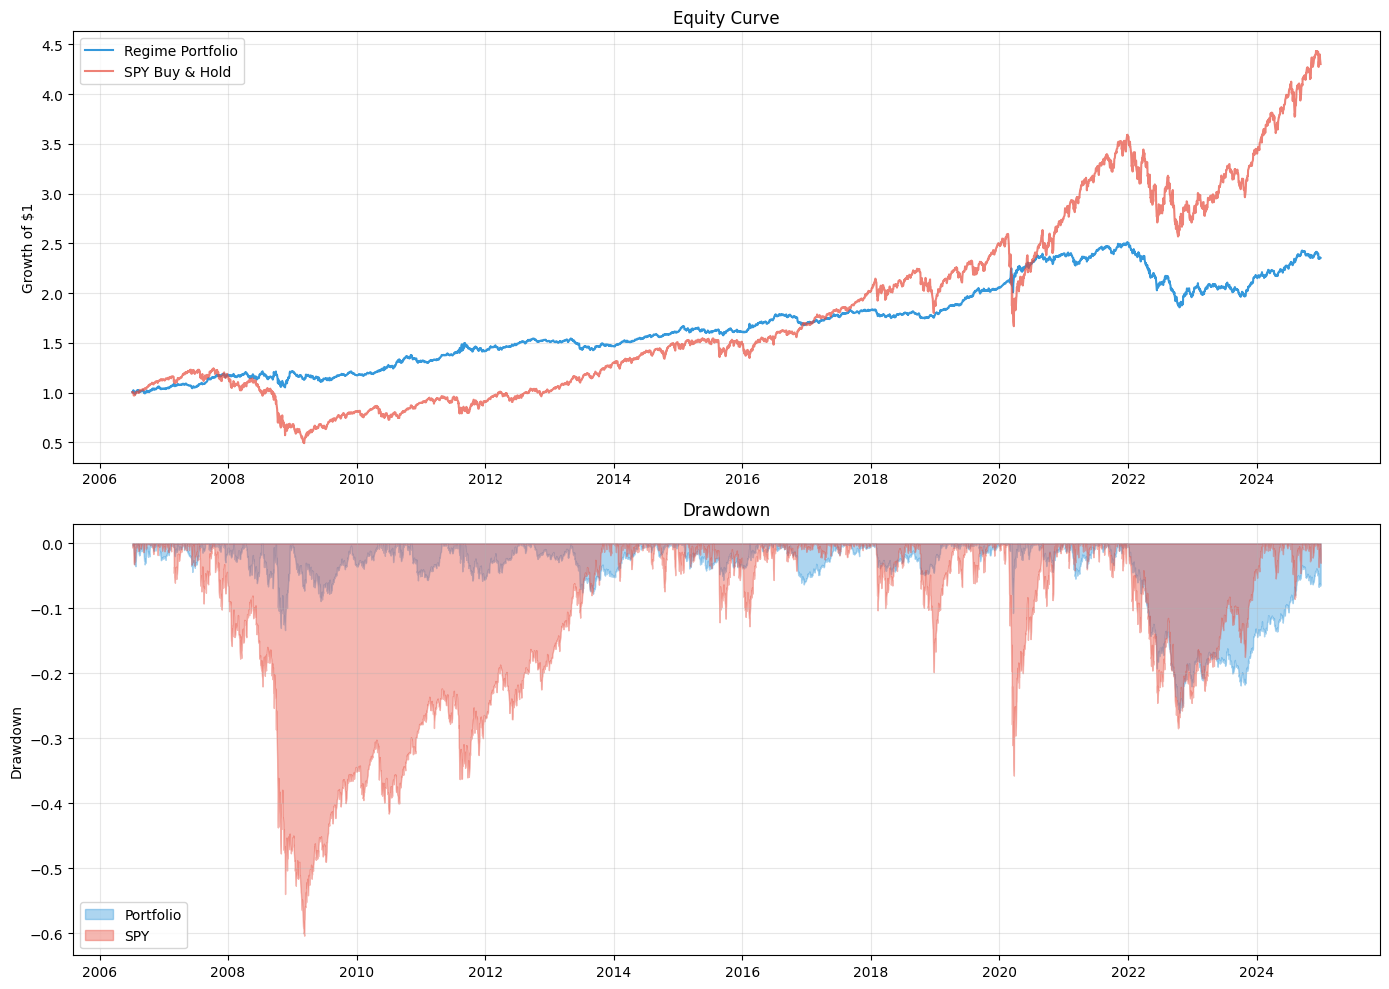

In [6]:
backtest = pd.read_parquet("../data/backtest_results.parquet")

common = backtest.index.intersection(returns.index)
spy_returns = returns.loc[common, "SPY"]
spy_equity = (1 + spy_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equity curves
axes[0].plot(backtest["equity"], label="Regime Portfolio", color="#3498db", linewidth=1.5)
axes[0].plot(spy_equity, label="SPY Buy & Hold", color="#e74c3c", linewidth=1.5, alpha=0.7)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

# Drawdown
port_dd = (backtest["equity"] - backtest["equity"].cummax()) / backtest["equity"].cummax()
spy_dd  = (spy_equity - spy_equity.cummax()) / spy_equity.cummax()

axes[1].fill_between(port_dd.index, port_dd, 0, alpha=0.4, color="#3498db", label="Portfolio")
axes[1].fill_between(spy_dd.index, spy_dd, 0, alpha=0.4, color="#e74c3c", label="SPY")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.1 Performance Metrics

In [7]:
from backtest.metrics import compute_all

port_metrics = compute_all(backtest["portfolio_return"], backtest["equity"])
spy_metrics  = compute_all(spy_returns, spy_equity)

metrics_df = pd.DataFrame({
    "Portfolio": port_metrics,
    "SPY": spy_metrics
})

metrics_df.index = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Calmar Ratio"
]

metrics_df

,Portfolio,SPY
Annualized Return,0.0475,0.0827
Annualized Volatility,0.0790,0.1958
Sharpe Ratio,0.6308,0.5048
Max Drawdown,-0.2606,-0.6039
Calmar Ratio,0.1822,0.1369


## 4. Posterior Probability Blending (v2)

In v2, the HMM outputs a full probability distribution over states for every day.
Instead of hard-switching to a single optimizer, weights are blended by posterior:

```
weights(t) = P(Bull|t) * w_bull + P(Bear|t) * w_bear + P(Sideways|t) * w_sideways + P(Crash|t) * w_crash
```

This is model-driven uncertainty ÔÇö the HMM's own confidence controls how aggressively we rotate.

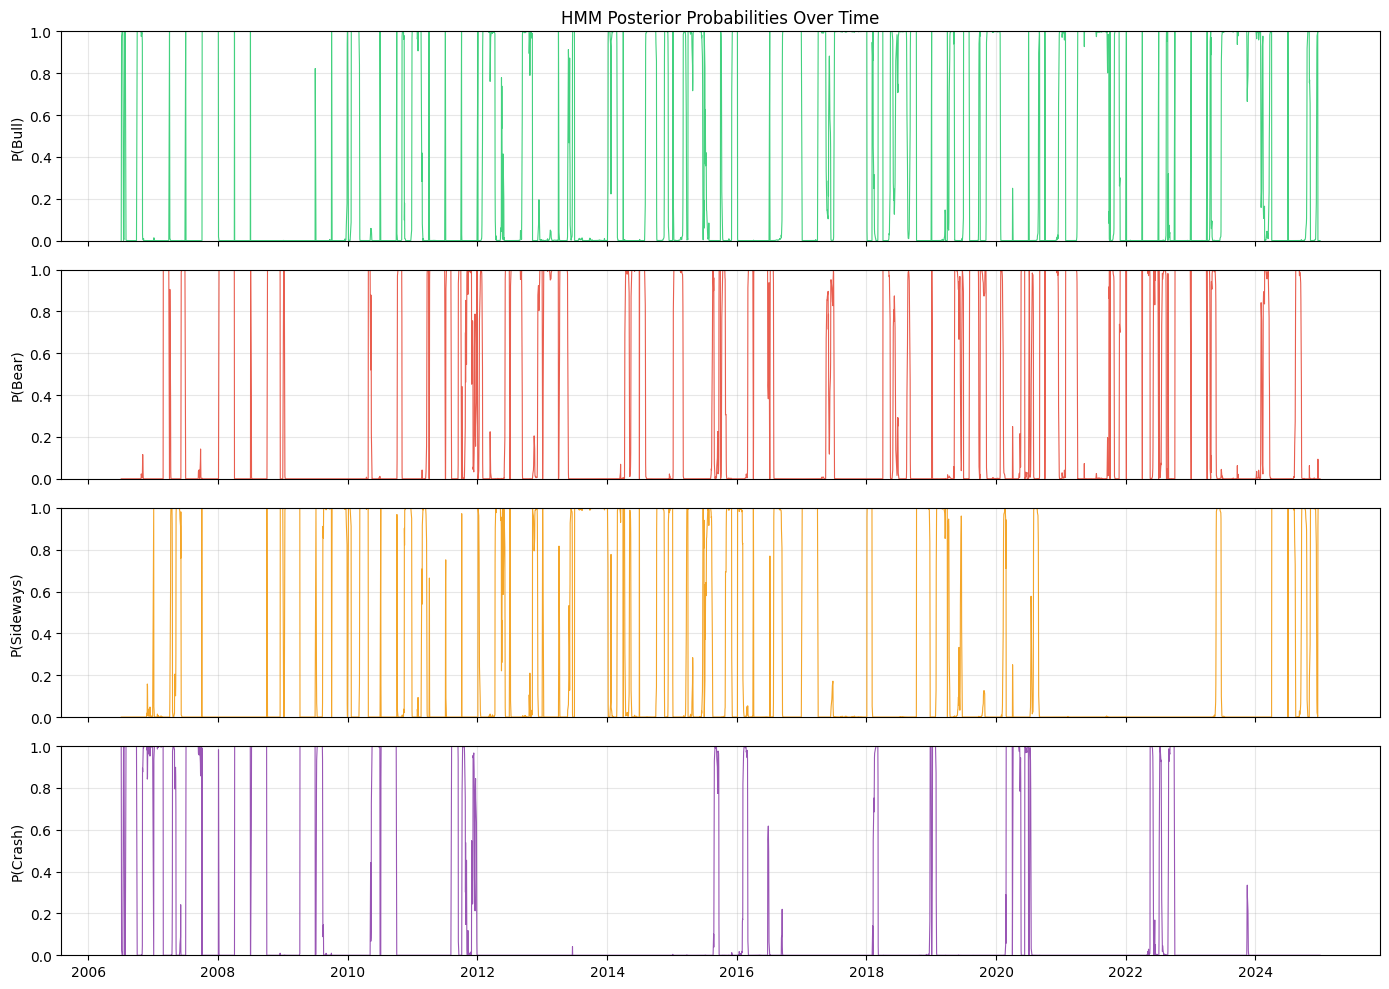

In [8]:
regimes = pd.read_parquet('../data/regimes.parquet')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, (col, label, color) in zip(axes, [
    ('p_bull',     'P(Bull)',     '#2ecc71'),
    ('p_bear',     'P(Bear)',     '#e74c3c'),
    ('p_sideways', 'P(Sideways)', '#f39c12'),
    ('p_crash',    'P(Crash)',    '#8e44ad')
]):
    if col in regimes.columns:
        ax.plot(regimes.index, regimes[col].fillna(0), color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1)

axes[0].set_title('HMM Posterior Probabilities Over Time')
plt.tight_layout()
plt.show()

## 5. Nested CV State Selection (v3)

At each quarterly retraining date, candidate state counts [2, 3, 4] are fitted on 80% of the available training window and scored by BIC on the held-out 20%. The state count minimizing BIC is selected independently per fold — early folds with less data may select n=2, later folds select n=3 or n=4.

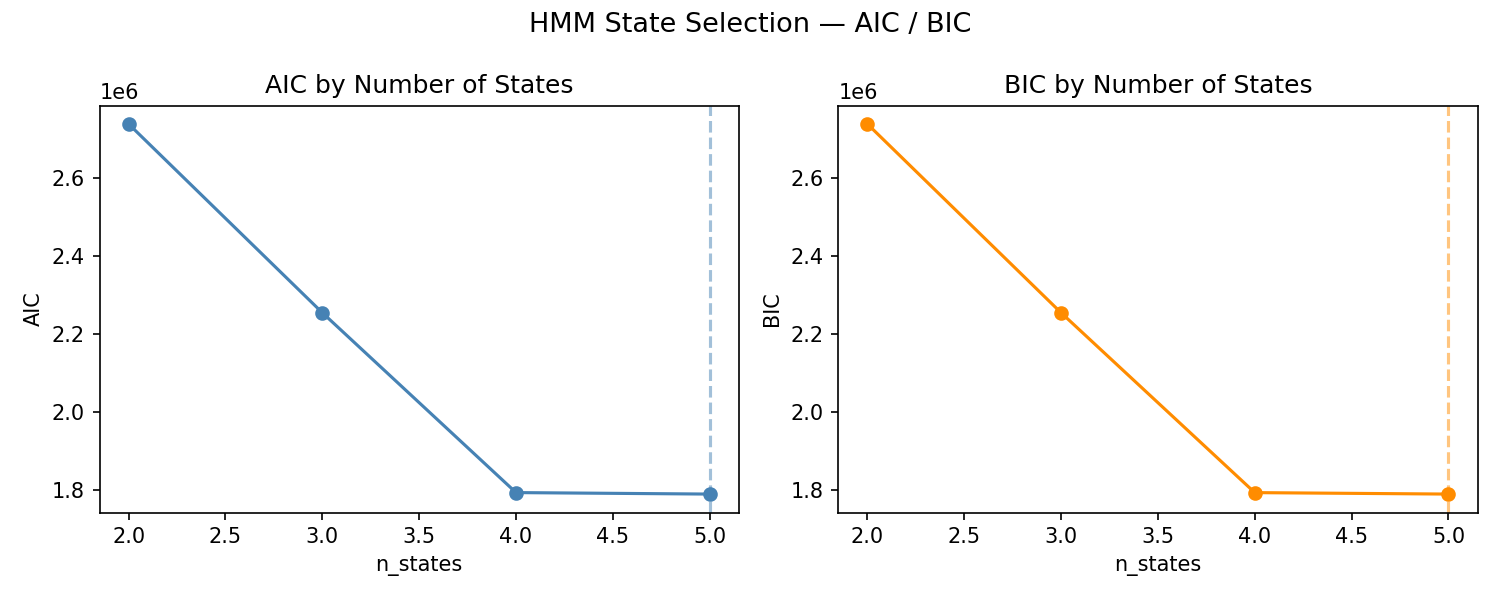

In [9]:
from IPython.display import Image
Image('../data/state_selection.png')

## 6. Expanded Benchmark Comparison (v2)

SPY alone is a weak baseline ÔÇö it carries full equity volatility.
v2 compares against Equal Weight, 60/40 (SPY + IEF), and 12-month Momentum.

In [10]:
from backtest.benchmark import (
    get_equal_weight_equity,
    get_sixty_forty_equity,
    get_momentum_equity,
    get_risk_parity_equity
)
from backtest.metrics import compute_all

backtest = pd.read_parquet('../data/backtest_results.parquet')
returns  = pd.read_parquet('../data/processed/returns.parquet')
common   = returns.index.intersection(backtest.index)
returns  = returns.loc[common]

spy_returns        = returns['SPY']
spy_equity         = (1 + spy_returns).cumprod()
ew_returns,  ew_equity  = get_equal_weight_equity(returns)
sf_returns,  sf_equity  = get_sixty_forty_equity(returns)
mom_returns, mom_equity = get_momentum_equity(returns)
rp_returns,  rp_equity  = get_risk_parity_equity(returns)

metrics_df = pd.DataFrame({
    'Portfolio':    compute_all(backtest['portfolio_return'], backtest['equity']),
    'SPY':          compute_all(spy_returns, spy_equity),
    'Equal Weight': compute_all(ew_returns, ew_equity),
    '60/40':        compute_all(sf_returns, sf_equity),
    'Momentum':     compute_all(mom_returns, mom_equity),
    'Risk Parity':  compute_all(rp_returns, rp_equity),
})

metrics_df.index = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'Calmar Ratio'
]

metrics_df

,Portfolio,SPY,Equal Weight,60/40,Momentum,Risk Parity
Annualized Return,0.0475,0.0827,0.0590,0.0680,0.0567,0.0455
Annualized Volatility,0.0790,0.1958,0.1119,0.1120,0.1322,0.0758
Sharpe Ratio,0.6308,0.5048,0.5675,0.6418,0.4853,0.6261
Max Drawdown,-0.2606,-0.6039,-0.3529,-0.3622,-0.2965,-0.2495
Calmar Ratio,0.1822,0.1369,0.1671,0.1877,0.1911,0.1823


## 7. Block Bootstrap Significance Test (v2)

Is the Sharpe outperformance statistically significant?

Block bootstrap with 1000 iterations and 20-day blocks preserves the autocorrelation
structure of financial returns. The p-value measures how often SPY beats the portfolio
in synthetic resampled runs.

In [11]:
from backtest.bootstrap import run_bootstrap, summarize

backtest    = pd.read_parquet('../data/backtest_results.parquet')
returns     = pd.read_parquet('../data/processed/returns.parquet')
common      = returns.index.intersection(backtest.index)
spy_returns  = returns.loc[common, 'SPY']
port_returns = backtest.loc[common, 'portfolio_return']

bootstrap_df = run_bootstrap(port_returns, spy_returns)
summary      = summarize(bootstrap_df)

pd.Series(summary)

mean_sharpe_diff     0.1294
std_sharpe_diff      0.3088
ci_lower            -0.4682
ci_upper             0.7372
p_value               0.347
significant_at_95     False
dtype: object

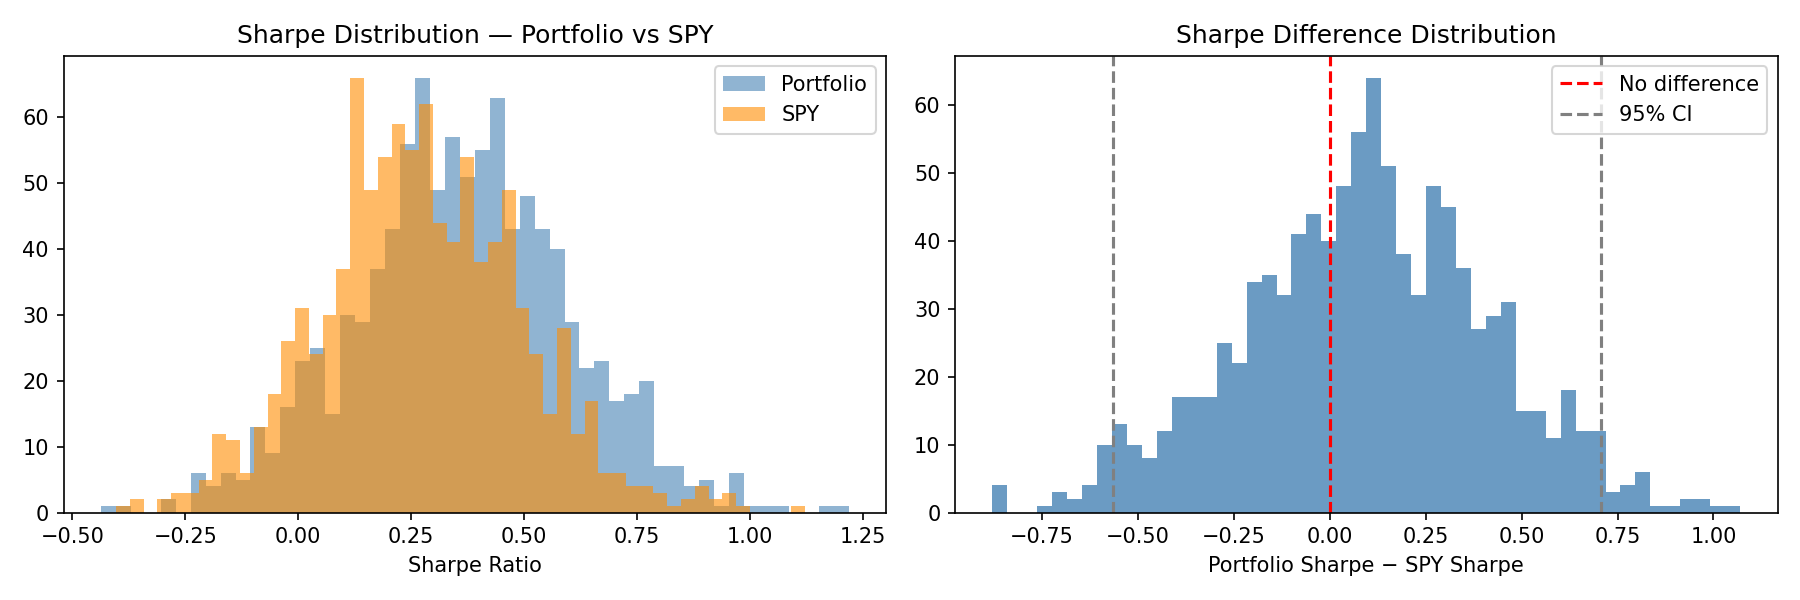

In [12]:
Image('../data/bootstrap.png')

## 8. Regime Transition Matrix & Persistence (v2)

The HMM transition matrix shows the probability of moving between regimes day-to-day.
High diagonal values confirm regime persistence — a core assumption of the HMM approach.

Average duration per regime is derived from the diagonal: `1 / (1 - A[i][i])`

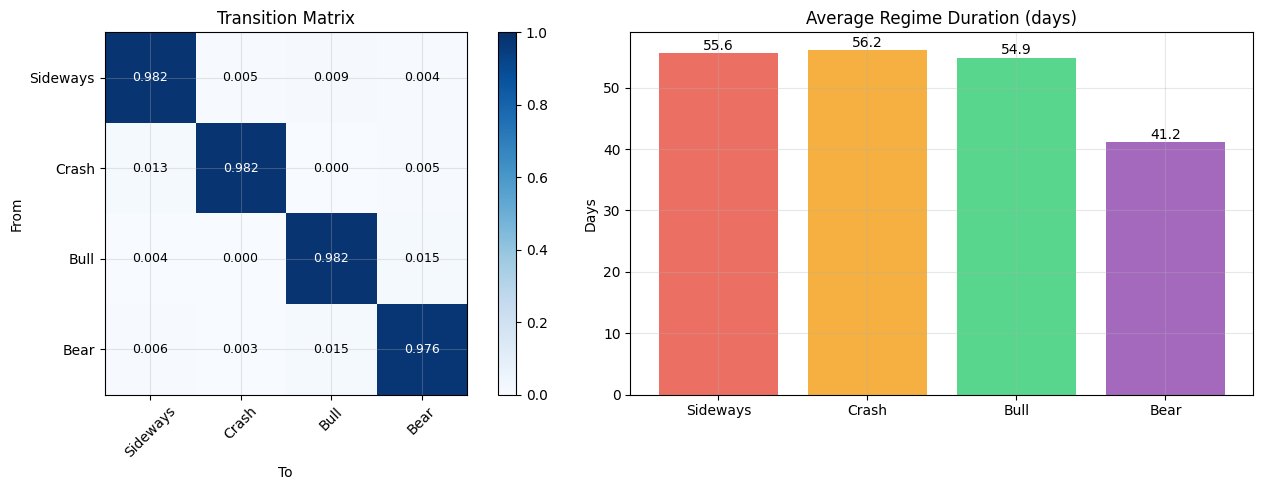

In [13]:
from models.hmm import load_model, load_features, label_states, get_transition_matrix, get_regime_durations
import matplotlib.pyplot as plt
import matplotlib
import os
os.chdir("..")  # move to project root if running from notebooks/

model, scaler = load_model()
df = load_features()
state_labels = label_states(model, df)
transmat = get_transition_matrix(model, state_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(transmat.values, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(transmat.columns)))
axes[0].set_yticks(range(len(transmat.index)))
axes[0].set_xticklabels(transmat.columns, rotation=45)
axes[0].set_yticklabels(transmat.index)
axes[0].set_title('Transition Matrix')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')
plt.colorbar(im, ax=axes[0])

for i in range(len(transmat.index)):
    for j in range(len(transmat.columns)):
        val = transmat.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=9)

# Duration bar chart
durations = get_regime_durations(transmat)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#8e44ad']
axes[1].bar(durations.index, durations.values, color=colors, alpha=0.8)
axes[1].set_title('Average Regime Duration (days)')
axes[1].set_ylabel('Days')
for i, (regime, val) in enumerate(durations.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
print('Transition Matrix:')
print(transmat.round(4))
print('\nAverage Regime Durations (days):')
print(get_regime_durations(transmat))

Transition Matrix:
          Sideways   Crash    Bull    Bear
Sideways    0.9820  0.0053  0.0087  0.0040
Crash       0.0127  0.9822  0.0000  0.0051
Bull        0.0036  0.0000  0.9818  0.0146
Bear        0.0064  0.0030  0.0149  0.9758

Average Regime Durations (days):
Sideways    55.6
Crash       56.2
Bull        54.9
Bear        41.2
Name: avg_duration_days, dtype: float64


## 9. Subperiod Analysis (v3)

Performance broken out across three structurally distinct market environments:
- **GFC (2008–2009):** Full crisis — tests downside protection
- **Low-vol bull (2013–2019):** Sustained bull market — tests upside capture cost
- **COVID+rates (2020–2024):** Mixed — fast crash, recovery, rate-driven bear

In [15]:
# ## 9. Subperiod Analysis (v3)

from backtest.engine import run_period
from config import load_config

CFG = load_config()
regimes_df = pd.read_parquet('data/regimes.parquet')
returns_full = pd.read_parquet('data/processed/returns.parquet')

all_results = []
for label, period in CFG["subperiods"].items():
    start, end = period["start"], period["end"]
    result, _ = run_period(start=start, end=end, regimes_df=regimes_df)
    spy_slice = returns_full.loc[start:end, "SPY"]
    spy_equity = (1 + spy_slice).cumprod()
    port_metrics = compute_all(result["portfolio_return"], result["equity"])
    spy_metrics = compute_all(spy_slice, spy_equity)
    for metric in port_metrics:
        all_results.append({
            "Period": label,
            "Metric": metric,
            "Portfolio": port_metrics[metric],
            "SPY": spy_metrics[metric]
        })

subperiod_df = pd.DataFrame(all_results).set_index(["Period", "Metric"])
subperiod_df

Portfolio     SPY
Period                   Metric                                  
GFC (2008-2009)          annualized_return        -0.0135 -0.1546
                         annualized_volatility     0.1247  0.3470
                         sharpe_ratio             -0.1118 -0.3234
                         max_drawdown             -0.1633 -0.5638
                         calmar_ratio             -0.0824 -0.2743
Low-vol bull (2013-2019) annualized_return         0.0597  0.1326
                         annualized_volatility     0.0658  0.1283
                         sharpe_ratio              0.9162  1.0622
                         max_drawdown             -0.0871 -0.1982
                         calmar_ratio              0.6854  0.6688
COVID+rates (2020-2024)  annualized_return         0.0224  0.1183
                         annualized_volatility     0.1149  0.2109
                         sharpe_ratio              0.2539  0.6452
                         max_drawdown             -0.2776 -0.3575
                         calmar_ratio              0.0806  0.3309

## 10. Jarque-Bera Normality Test per Regime (v3)

The Gaussian HMM assumes returns within each regime are normally distributed. Jarque-Bera tests this assumption by measuring skewness and excess kurtosis jointly. A p-value below 0.05 rejects normality.


In [16]:
from scipy.stats import jarque_bera

regimes_df = pd.read_parquet('data/regimes.parquet')
records = []
for regime in ["Bull", "Bear", "Sideways", "Crash"]:
    subset = regimes_df[regimes_df["regime"] == regime]["spy_return"]
    jb_stat, p_value = jarque_bera(subset)
    records.append({
        "Regime": regime,
        "N": len(subset),
        "Skew": round(subset.skew(), 3),
        "Kurtosis": round(subset.kurtosis(), 3),
        "JB Stat": round(jb_stat, 2),
        "p-value": round(p_value, 4),
        "Normal?": "Yes" if p_value > 0.05 else "No"
    })

pd.DataFrame(records).set_index("Regime")

,N,Skew,Kurtosis,JB Stat,p-value,Normal?
Regime,,,,,,
Bull,1309,-0.517,2.838,492.84,0.0,No
Bear,1448,0.053,14.317,12275.92,0.0,No
Sideways,1099,-0.260,5.411,1338.05,0.0,No
Crash,764,-0.751,7.388,1782.75,0.0,No


## 11. Window Sensitivity Sweep (v4)

Full pipeline rerun across VOL_WINDOW ∈ {10, 21, 42} × CORR_WINDOW ∈ {42, 63, 126}. Tests whether the default parameters are cherry-picked or sit in a stable region.

In [17]:
sensitivity = pd.read_csv('data/sensitivity_results.csv')

pivot_sharpe = sensitivity.pivot(index='vol_window', columns='corr_window', values='sharpe')
pivot_held = sensitivity.pivot(index='vol_window', columns='corr_window', values='held_out_sharpe')

print("Full-sample Sharpe by (VOL_WINDOW, CORR_WINDOW):")
print(pivot_sharpe.round(3))
print("\nHeld-out Sharpe by (VOL_WINDOW, CORR_WINDOW):")
print(pivot_held.round(3))

print(f"\nDefault (VOL=21, CORR=63) full Sharpe:    {sensitivity[(sensitivity.vol_window==21) & (sensitivity.corr_window==63)]['sharpe'].values[0]:.3f}")
print(f"Default (VOL=21, CORR=63) held-out Sharpe: {sensitivity[(sensitivity.vol_window==21) & (sensitivity.corr_window==63)]['held_out_sharpe'].values[0]:.3f}")


Full-sample Sharpe by (VOL_WINDOW, CORR_WINDOW):
corr_window    42     63     126
vol_window                      
10           0.374  0.621  0.613
21           0.525  0.534  0.622
42           0.384  0.524  0.486

Held-out Sharpe by (VOL_WINDOW, CORR_WINDOW):
corr_window    42     63     126
vol_window                      
10           0.323  0.799  0.638
21           0.488  0.760  0.711
42           0.271  0.768  0.579

Default (VOL=21, CORR=63) full Sharpe:    0.533
Default (VOL=21, CORR=63) held-out Sharpe: 0.760
